<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Lesson_15_Assignment_15-AK/blob/main/Lesson_15_Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 15: Loan Default Prediction

Task 1: Data Analysis and Cleaning

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
# 1.2 Load & Explore the Dataset
# Load dataset
df = pd.read_csv("bank-loan.csv")

df.head()
print("Dataset Shape:")
print(df.shape)
print(df.columns)
df.info()

Dataset Shape:
(850, 9)
Index(['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt',
       'othdebt', 'default'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


2. Exploratory Data Analysis (EDA)

In [3]:
# 2.1 Summary Statistics
df.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


In [4]:
# 2.2 Check Missing Values
df.isnull().sum()

,0
age,0
ed,0
employ,0
address,0
income,0
debtinc,0
creddebt,0
othdebt,0
default,150


In [6]:
# 2.3 Check Duplicate Records
df.duplicated().sum()
df = df.drop_duplicates()

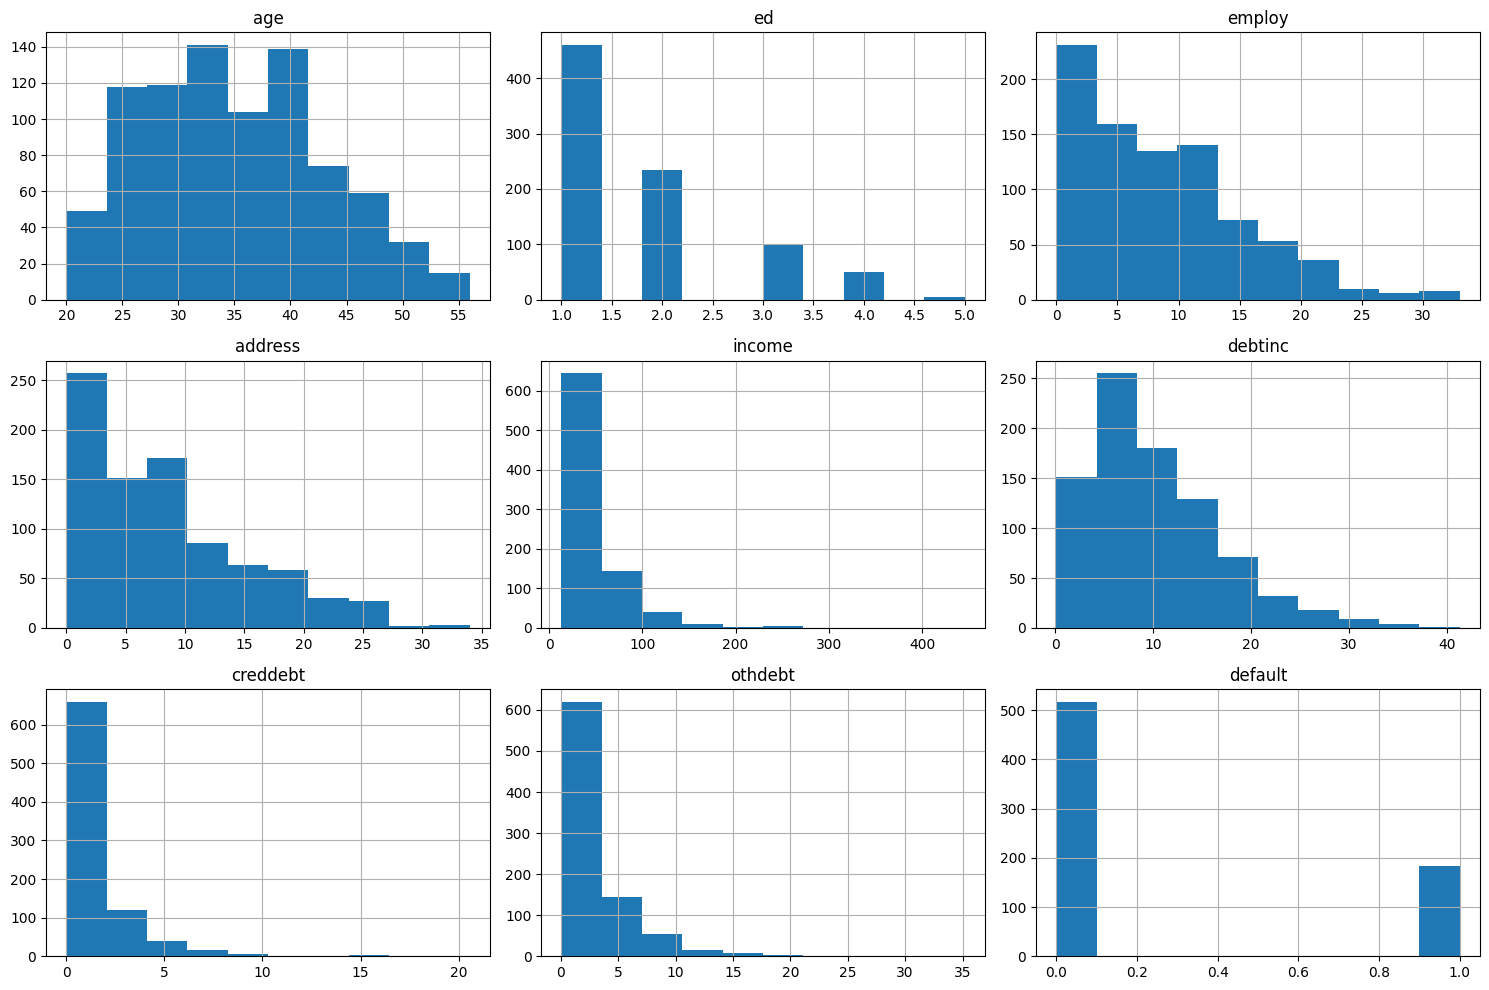

In [7]:
# 2.4 Distribution of Numerical Variables
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

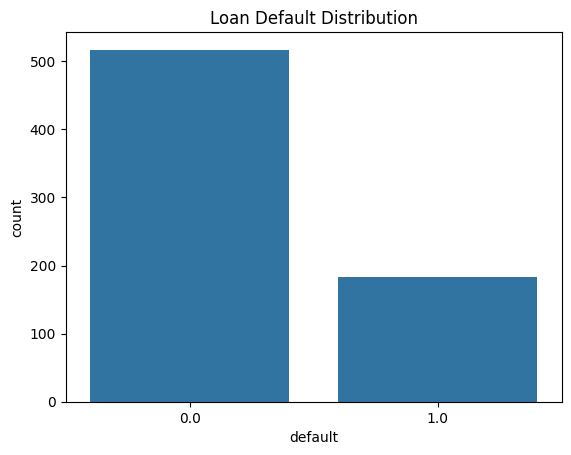

In [8]:
# 2.5 Loan Default Distribution
sns.countplot(x='default', data=df)
plt.title("Loan Default Distribution")
plt.show()

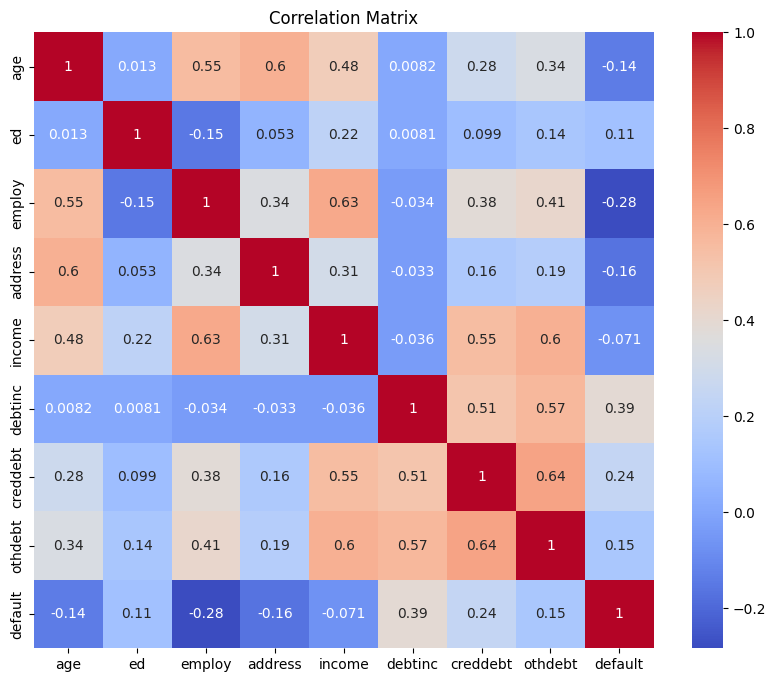

In [9]:
# 2.6 Correlation Matrix
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

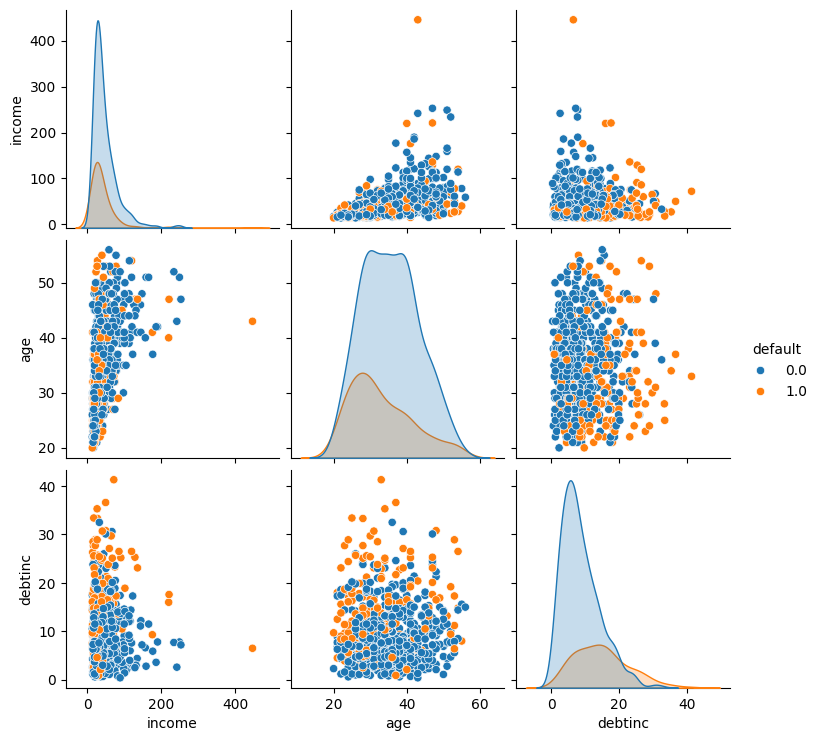

In [10]:
# 2.7 Pair Plot
sns.pairplot(df[['income',
                 'age',
                 'debtinc',
                 'default']],
             hue='default')

plt.show()

3. Data Cleaning

In [11]:
# 3.1 Handle Missing Values
# For numerical variables
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column].fillna(df[column].median(), inplace=True)

/tmp/ipykernel_31538/2764579238.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)


In [12]:
#For categorical variables:

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

In [13]:
# 3.2 Encode Categorical Variables
label_encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [14]:
# 3.3 Normalize Numerical Features
scaler = StandardScaler()

numerical_columns = df.drop('default', axis=1).select_dtypes(include=np.number).columns

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

4. Verify Clean Dataset

In [15]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    float64
 1   ed        850 non-null    float64
 2   employ    850 non-null    float64
 3   address   850 non-null    float64
 4   income    850 non-null    float64
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   850 non-null    float64
dtypes: float64(9)
memory usage: 59.9 KB


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,850.000000
mean,-2.048035e-16,-1.086712e-16,-7.105427e-17,8.777293e-17,8.359326e-17,2.298815e-17,9.195259e-17,1.003119e-16,0.215294
std,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,0.411268
min,-1.870097e+00,-7.663494e-01,-1.264543e+00,-1.214891e+00,-8.742203e-01,-1.499764e+00,-7.366642e-01,-8.929588e-01,0.000000
25%,-7.502348e-01,-7.663494e-01,-8.216664e-01,-7.795380e-01,-5.886572e-01,-7.552165e-01,-5.622869e-01,-5.984589e-01,0.000000
50%,-1.280889e-01,-7.663494e-01,-2.311642e-01,-1.990673e-01,-3.030940e-01,-2.191423e-01,-3.255751e-01,-3.166349e-01,0.000000
75%,7.429154e-01,3.121224e-01,6.545890e-01,5.265211e-01,2.355820e-01,5.402963e-01,1.513873e-01,2.426432e-01,0.000000
max,2.609353e+00,3.547538e+00,3.607100e+00,3.719110e+00,1.036658e+01,4.635308e+00,8.935612e+00,9.455570e+00,1.000000


Task 1 Conclusion

The loan dataset was successfully explored and prepared for machine learning. Exploratory Data Analysis provided insight into the distribution of borrower characteristics and relationships among variables. Data cleaning addressed missing values, duplicate records, and categorical encoding, while feature normalization ensured consistent scaling across numerical variables. The cleaned dataset is now suitable for the next stage of the assignment: Feature Engineering and Feature Scaling, as required by the assignment.

Task 2: Feature Engineering

In [16]:
# 2.1 Examine Existing Features
print(df.columns)

Index(['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt',
       'othdebt', 'default'],
      dtype='object')


In [17]:
# 2.3 Create New Features
# Feature 1: Total Debt / The total debt combines credit debt and other debt into a single financial indicator.

df["total_debt"] = df["creddebt"] + df["othdebt"]

In [28]:
# Feature 2: Income per Household Member
# The 'reside' column is not present in the dataset, so this feature cannot be created as defined.
# df["income_per_person"] = df["income"] / (df["reside"] + 1)

In [30]:
# Feature 3: Employment Stability
df["employment_income_ratio"] = df["employ"] / (df["income"] + 1)

In [31]:
# Feature 4: Debt Burden
df["debt_income_product"] = df["income"] * df["debtinc"]

In [74]:
# Feature 5: Age Group
# Original age mean and std from initial data loading and description (cell _ziXuBiZXxBr output)
# These values are hardcoded based on the df.describe() output for the original 'age' column.
mean_age_orig = 35.029412
std_age_orig = 8.041432

# Original age bins
original_bins = [18, 30, 40, 50, 70]
original_labels = ["Young","Adult","Middle","Senior"]

# Temporarily unscale the 'age' column for pd.cut to use original bins directly
# This ensures pd.cut works as expected with familiar age ranges.
original_age_values = (df['age'] * std_age_orig) + mean_age_orig

print(f"Original (unscaled) age values min: {original_age_values.min():.2f}, max: {original_age_values.max():.2f}")
print(f"Original bins: {original_bins}")

df["age_group"] = pd.cut(
    original_age_values, # Use unscaled age here
    bins=original_bins,  # Use original bins here
    labels=original_labels,
    include_lowest=True,
    ordered=True
)

print("\nAfter pd.cut, df['age_group'] value counts (including NaNs):")
print(df['age_group'].value_counts(dropna=False))
print(f"df['age_group'] dtype after pd.cut: {df['age_group'].dtype}")

# Robust fillna for age_group
if df['age_group'].isnull().all(): # If pd.cut resulted in all NaNs
    df['age_group'] = original_labels[0] # Assign a default label
    print("Warning: All 'age_group' values were NaN after pd.cut. Assigned default label.")
elif df['age_group'].isnull().any(): # If some values are NaN
    # Convert to object type temporarily to handle potential Categorical issues with mode() if all non-NaN are the same
    temp_age_group = df['age_group'].astype(object)
    most_frequent_label = temp_age_group.mode()[0]
    df['age_group'] = df['age_group'].fillna(most_frequent_label)
    print(f"Filled NaN 'age_group' values with '{most_frequent_label}'.")

print("\nFinal age group distribution after fillna:")
print(df['age_group'].value_counts(dropna=False))
print(f"Final df['age_group'] dtype: {df['age_group'].dtype}")

Original (unscaled) age values min: 19.99, max: 56.01
Original bins: [18, 30, 40, 50, 70]

After pd.cut, df['age_group'] value counts (including NaNs):
age_group
Adult     316
Young     286
Middle    206
Senior     42
Name: count, dtype: int64
df['age_group'] dtype after pd.cut: category

Final age group distribution after fillna:
age_group
Adult     316
Young     286
Middle    206
Senior     42
Name: count, dtype: int64
Final df['age_group'] dtype: category


In [33]:
# 2.4 Display Newly Created Features
df[[
    "total_debt",
    "employment_income_ratio",
    "debt_income_product",
    "age_group"
]].head()

,total_debt,employment_income_ratio,debt_income_product,age_group
0,2.851782,0.285748,-0.435767,NaN
1,0.093960,0.356980,-0.431953,NaN
2,-0.334705,0.781047,-0.150339,NaN
3,-0.085656,0.327133,-2.061176,NaN
4,0.051051,-1.881448,-0.514622,NaN


In [75]:
# 2.5 Encode the New Categorical Feature
# The newly created Age Group variable is categorical and must be converted into numerical values.

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# Ensure the column is of string/object type before encoding for robustness
df["age_group"] = df["age_group"].astype(str)

print(f"df['age_group'] unique values before encoding: {df['age_group'].unique()}")
df["age_group"] = encoder.fit_transform(df["age_group"])
print(f"df['age_group'] unique values after encoding: {df['age_group'].unique()}")

df['age_group'] unique values before encoding: ['Middle' 'Young' 'Adult' 'Senior']
df['age_group'] unique values after encoding: [1 3 0 2]


In [35]:
# 2.6 Scale Numerical Features

# Machine learning algorithms perform better when numerical variables are on similar scales.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "age",
    "income",
    "employ",
    "address",
    "debtinc",
    "creddebt",
    "othdebt",
    # "reside", # 'reside' column is not in the DataFrame
    "total_debt",
    # "income_per_person", # 'income_per_person' is not created due to missing 'reside'
    "employment_income_ratio",
    "debt_income_product"
]

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [36]:
# 2.7 Verify the Scaled Dataset
df.head()
df.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,total_debt,employment_income_ratio,debt_income_product,age_group
count,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,8.500000e+02,850.000000,850.000000,8.500000e+02,8.500000e+02,850.0
mean,1.253899e-17,-1.086712e-16,-4.179663e-18,1.044916e-17,-1.671865e-17,1.776357e-17,-8.359326e-18,4.179663e-18,0.215294,0.000000,-2.507798e-17,-4.179663e-18,0.0
std,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,1.000589e+00,0.411268,1.000589,1.000589e+00,1.000589e+00,0.0
min,-1.870097e+00,-7.663494e-01,-1.264543e+00,-1.214891e+00,-8.742203e-01,-1.499764e+00,-7.366642e-01,-8.929588e-01,0.000000,-0.894571,-4.109245e+00,-7.693864e+00,0.0
25%,-7.502348e-01,-7.663494e-01,-8.216664e-01,-7.795380e-01,-5.886572e-01,-7.552165e-01,-5.622869e-01,-5.984589e-01,0.000000,-0.593462,-5.195698e-01,-2.617370e-01,0.0
50%,-1.280889e-01,-7.663494e-01,-2.311642e-01,-1.990673e-01,-3.030940e-01,-2.191423e-01,-3.255751e-01,-3.166349e-01,0.000000,-0.320056,3.032844e-01,6.769595e-02,0.0
75%,7.429154e-01,3.121224e-01,6.545890e-01,5.265211e-01,2.355820e-01,5.402963e-01,1.513873e-01,2.426432e-01,0.000000,0.178687,7.117264e-01,3.921034e-01,0.0
max,2.609353e+00,3.547538e+00,3.607100e+00,3.719110e+00,1.036658e+01,4.635308e+00,8.935612e+00,9.455570e+00,1.000000,8.320764,1.579384e+00,9.994796e+00,0.0


In [37]:
# 2.8 Save the Processed Dataset
df.to_csv("loan_clean_feature_engineered.csv", index=False)

print("Feature engineering completed successfully.")

Feature engineering completed successfully.


Task 3: Model Building and Evaluation

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [39]:
# Load the Feature-Engineered Dataset
df = pd.read_csv("loan_clean_feature_engineered.csv")

In [40]:
# 3.3 Define Features and Target Variable

# The target variable is default, where:
# 0 = No Loan Default
# 1 = Loan Default
X = df.drop("default", axis=1)
y = df["default"]

In [41]:
# 3.4 Split the Dataset into Training and Testing Sets

# The dataset is divided into:
# 80% Training Data
# 20% Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [42]:
# 3.5 Train the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [43]:
# 3.6 Predict Loan Defaults
y_pred = rf_model.predict(X_test)

In [44]:
# 3.7 Model Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.788235294117647


In [45]:
# 3.8 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[122  11]
 [ 25  12]]


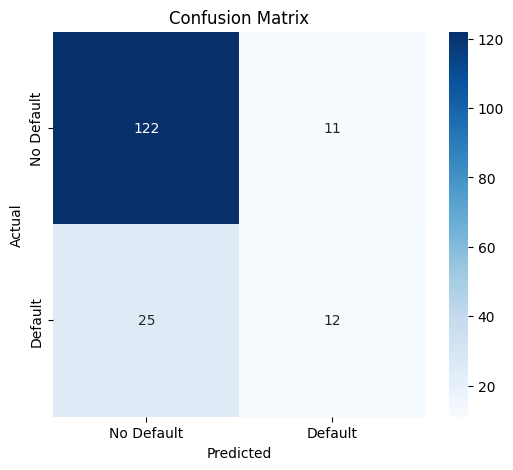

In [46]:
# Visualize the Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default","Default"],
    yticklabels=["No Default","Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
# 3.9 Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.92      0.87       133
         1.0       0.52      0.32      0.40        37

    accuracy                           0.79       170
   macro avg       0.68      0.62      0.64       170
weighted avg       0.76      0.79      0.77       170



In [48]:
# 3.10 Feature Importance Analysis

# Random Forest provides an estimate of the contribution of each feature toward predicting loan defaults.
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                    Feature  Importance
5                   debtinc    0.143463
9   employment_income_ratio    0.120102
6                  creddebt    0.106436
2                    employ    0.102437
8                total_debt    0.093523
10      debt_income_product    0.092098
7                   othdebt    0.084846
0                       age    0.081366
4                    income    0.073396
3                   address    0.071339
1                        ed    0.030994
11                age_group    0.000000


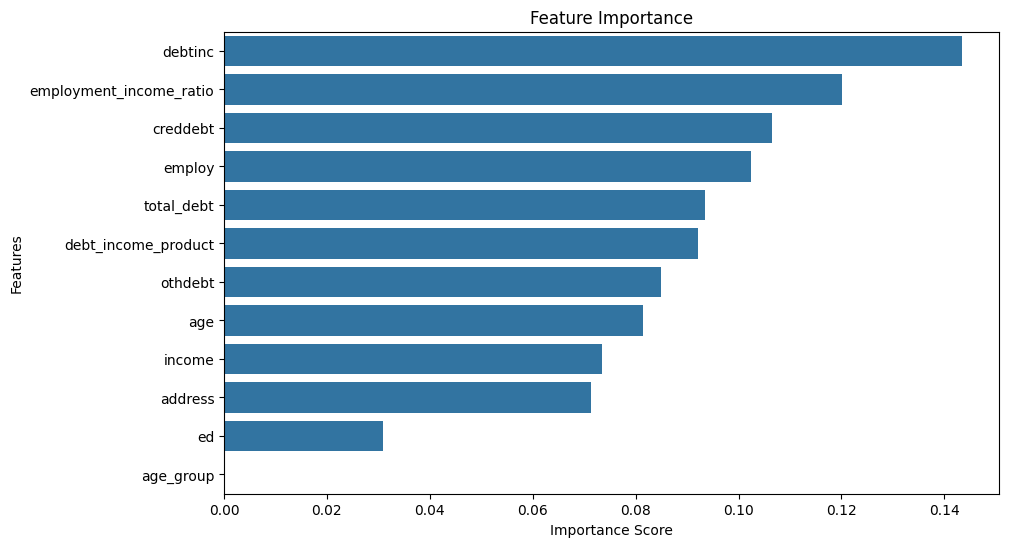

In [49]:
# Visualize Feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Task 4: Explainability and Fairness Analysis

In [50]:
# 4.1 Import Required Libraries
import shap
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [51]:
# 4.2 Load the Feature-Engineered Dataset
df = pd.read_csv("loan_clean_feature_engineered.csv")

# 4.3 Prepare Features and Target Variable
X = df.drop("default", axis=1)

y = df["default"]

In [52]:
# 4.4 Train the Random Forest Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [53]:
# 4.5 Generate SHAP Values: Random Forest is a tree-based model, so TreeExplainer is used.

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

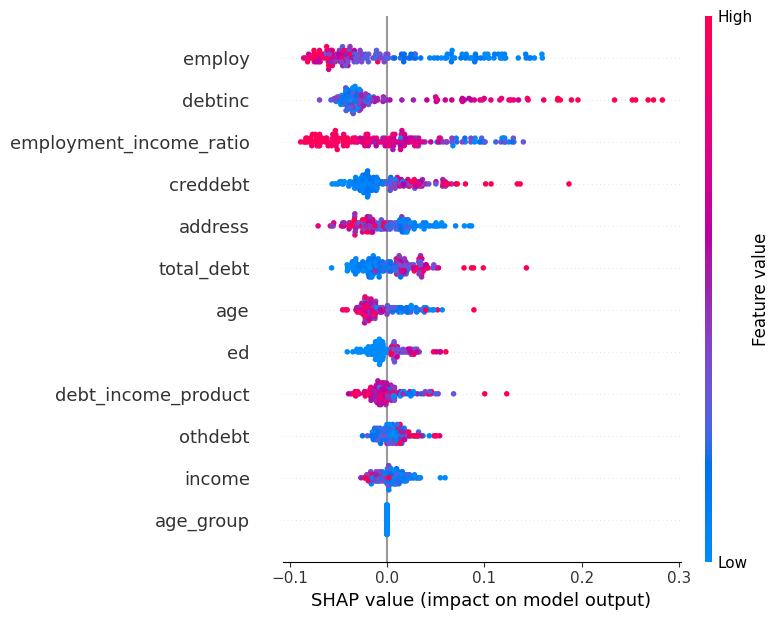

In [55]:
# 4.6 SHAP Summary Plot
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

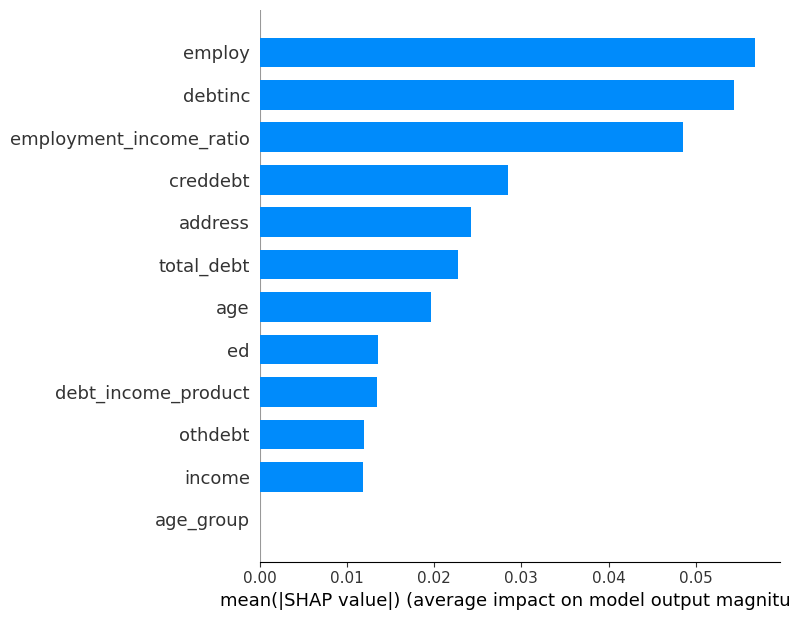

In [58]:
# 4.7 SHAP Bar Plot
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

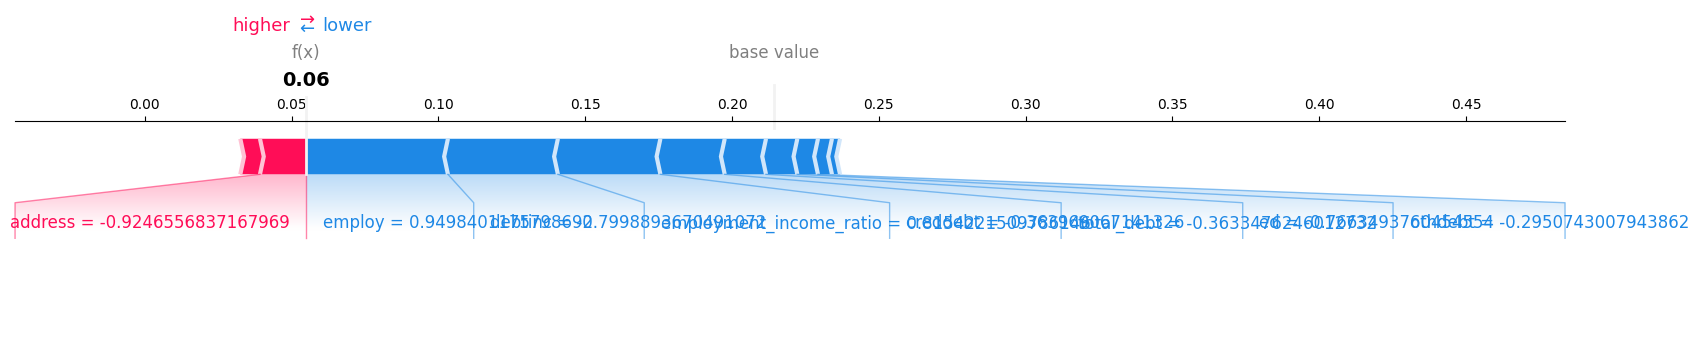

In [59]:
# 4.8 Explain an Individual Prediction
sample_index = 0 # You can change this to explain a different sample
sample = X_test.iloc[sample_index]

shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_index, :, 1],
    sample,
    matplotlib=True
)

In [76]:
# 4.9 Fairness Analysis

# Separate Predictions by Age Group (using the first two unique encoded values)
unique_age_groups = df['age_group'].unique()

if len(unique_age_groups) >= 2:
    # Convert to list before sorting to avoid AttributeError if it's a Categorical object
    # or to ensure consistent sorting behavior for numpy arrays of integers.
    unique_age_groups_list = sorted(list(unique_age_groups))

    group_a_value = unique_age_groups_list[0]
    group_b_value = unique_age_groups_list[1]

    group_a = df[df["age_group"] == group_a_value].copy()
    group_b = df[df["age_group"] == group_b_value].copy()

    print(f"Fairness analysis will be performed on 'age_group' with values {group_a_value} and {group_b_value}")
else:
    print("Not enough unique age groups for fairness analysis. Need at least two. Found:", list(unique_age_groups))
    group_a = pd.DataFrame()
    group_b = pd.DataFrame()

Fairness analysis will be performed on 'age_group' with values 0 and 1


In [64]:
# Create a Function for Fairness Evaluation
def evaluate_group(group):

    X_group = group.drop("default", axis=1)
    y_group = group["default"]
    predictions = rf_model.predict(X_group)
    accuracy = accuracy_score(y_group, predictions)

    return accuracy

In [77]:
# Evaluate Group A
if not group_a.empty:
    # Ensure group_a_value is defined before using it in the f-string
    # It should be defined if len(unique_age_groups) >= 2 condition is met in wad9ina9pZwb.
    # Using a local check for robustness.
    if 'group_a_value' in locals() and group_a_value is not None:
        group_a_accuracy = evaluate_group(group_a)
        print(f"Group A Accuracy (age_group={{group_a_value}}):", group_a_accuracy)
    else:
        print("Group A is empty or group_a_value is not defined, skipping evaluation.")
else:
    print("Group A is empty, skipping evaluation.")

Group A Accuracy (age_group={group_a_value}): 0.9683544303797469


In [78]:
# Evaluate Group B
if not group_b.empty:
    # Ensure group_b_value is defined before using it in the f-string
    # It should be defined if len(unique_age_groups) >= 2 condition is met in wad9ina9pZwb.
    # Using a local check for robustness.
    if 'group_b_value' in locals() and group_b_value is not None:
        group_b_accuracy = evaluate_group(group_b)
        print(f"Group B Accuracy (age_group={{group_b_value}}):", group_b_accuracy)
    else:
        print("Group B is empty or group_b_value is not defined, skipping evaluation.")
else:
    print("Group B is empty, skipping evaluation.")

Group B Accuracy (age_group={group_b_value}): 0.9563106796116505


Task 5: Ethical Considerations